# Import libs

In [10]:
from __future__ import print_function
import matplotlib.pyplot as plt
%matplotlib inline

import argparse
import os
import cv2
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np

import torch
import torch.optim

import scipy.io
from scipy.io import savemat
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim
from models.downsampler import Downsampler
from models.resnet import ResNet
from models.unet import UNet
from models.skip import skip

from utils.sr_utils import *

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

# Load image and baselines

In [11]:
def convert_png_to_mat(input_path, output_path):
    """
    Convert a PNG image to MAT file format suitable for the super-resolution model.
    
    Args:
        input_path (str): Path to the input PNG image
        output_path (str): Path to save the output MAT file
    """
    # Read the image
    img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    img = img / 255.0
    
    # Resize to create HR, LR, bicubic, and nearest images
    HR = cv2.resize(img, (192, 192))
    LR = cv2.resize(HR, (96, 96))
    bicubic = cv2.resize(LR, (192, 192), interpolation=cv2.INTER_CUBIC)
    nearest = cv2.resize(LR, (192, 192), interpolation=cv2.INTER_NEAREST)
    
    # Create synthetic bands by applying brightness variations
    def create_bands(image, num_bands=102):
        bands = [image]
        for i in range(1, num_bands):
            factor = 1 + (i * 0.1)
            band = np.clip(image * factor, 0, 1)
            bands.append(band)
        return np.stack(bands, axis=-1)
    
    # Create multi-band versions of each image
    HR = create_bands(HR, num_bands=102)
    LR = create_bands(LR, num_bands=102)
    bicubic = create_bands(bicubic, num_bands=102)
    nearest = create_bands(nearest, num_bands=102)
    
    # Create the output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Save the processed images to a MAT file
    savemat(output_path, {'HR': HR, 'LR': LR, 'bicubic': bicubic, 'nearest': nearest})
    print(f"Saved preprocessed image for super-resolution model to {output_path}")
    return output_path

Saved preprocessed image for super-resolution model to data/sr/demo_img.mat


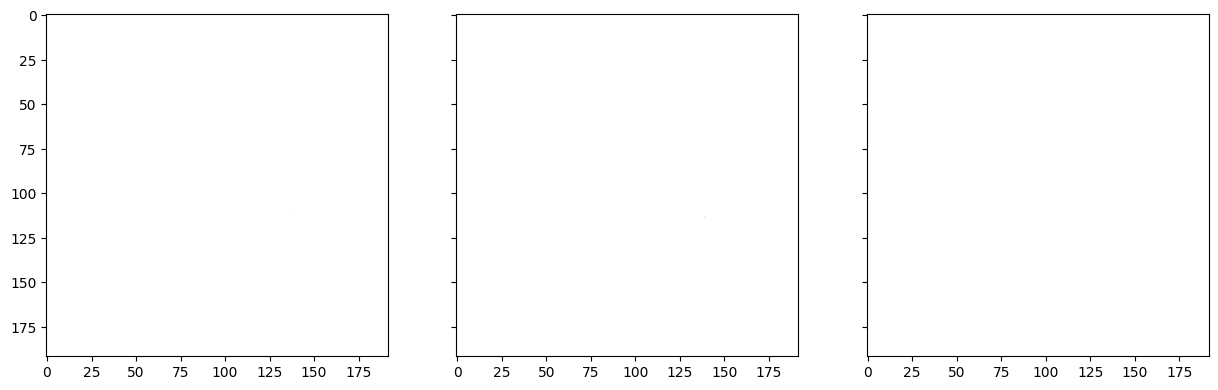

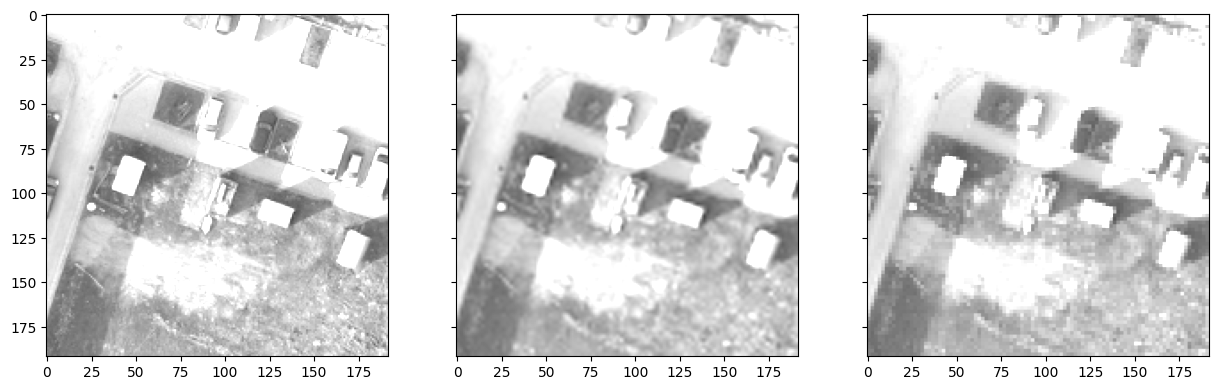

PSNR bicubic: 34.7414   PSNR nearest: 33.8499   SSIM bicubic: 0.9639   SSIM nearest: 0.9617


In [12]:
input_image = "data/input_imgs/demo_img.png"
output_mat = "data/sr/demo_img.mat"
convert_png_to_mat(input_image, output_mat)

file_name  = 'data/sr/sr.mat'

# imgs contains ['HR'] ['LR'] ['bicubic'] ['nearest']
# ensure dimensions [0][1] are divisible by 32 (or 2^depth)!
# imgs = scipy.io.loadmat(file_name)
imgs = scipy.io.loadmat(output_mat)

factor = 2 

#plot band
band = 24

f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15,15))
ax1.imshow(imgs['HR'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
ax2.imshow(imgs['bicubic'][:,:,band], cmap='gray', vmin=0, vmax=0.5) 
ax3.imshow(imgs['nearest'][:,:,band], cmap='gray', vmin=0, vmax=0.5)
plt.show()

#plot band
band = 0

f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15,15))
ax1.imshow(imgs['HR'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
ax2.imshow(imgs['bicubic'][:,:,band], cmap='gray', vmin=0, vmax=0.5) 
ax3.imshow(imgs['nearest'][:,:,band], cmap='gray', vmin=0, vmax=0.5)
plt.show()

print('PSNR bicubic: %.4f   PSNR nearest: %.4f   SSIM bicubic: %.4f   SSIM nearest: %.4f' %  (
    compare_psnr(imgs['HR'], imgs['bicubic']), 
    compare_psnr(imgs['HR'], imgs['nearest']),
    compare_ssim(imgs['HR'], imgs['bicubic'], channel_axis=2, data_range=1.0),
    compare_ssim(imgs['HR'], imgs['nearest'], channel_axis=2, data_range=1.0)))

# Set up parameters and net

In [4]:
input_depth = imgs['HR'].shape[2]

method =    '2D'
pad   =     'reflection'
OPT_OVER =  'net'
KERNEL_TYPE='lanczos2'

show_every = 500
save_every = 2000

LR = 0.01
tv_weight = 0.0

OPTIMIZER = 'adam'

num_iter = 12001
reg_noise_std = 0.01  # try 0 0.03 0.05 0.08

In [5]:
print(imgs['HR'][0].shape)

(192, 102)


In [ ]:
net_input = get_noise(input_depth, method, (imgs['HR'].shape[0], imgs['HR'].shape[1])).type(dtype).detach()

net = skip(input_depth, imgs['HR'].shape[2],
           num_channels_down = [128]*5,
           num_channels_up =   [128]*5,
           num_channels_skip =    [4]*5,  
           filter_size_up = 3,filter_size_down = 3,  filter_skip_size=1,
           upsample_mode='bilinear', # downsample_mode='avg',
           need1x1_up=False,
           need_sigmoid=False, need_bias=True, pad=pad, act_fun='LeakyReLU').type(dtype)

# Losses
mse = torch.nn.MSELoss().type(dtype)

img_LR_var = imgs['LR'].transpose(2,0,1)
img_LR_var = torch.from_numpy(img_LR_var).type(dtype)
img_LR_var = img_LR_var[None, :].cuda()

downsampler = Downsampler(n_planes=imgs['HR'].shape[2], factor=factor, kernel_type=KERNEL_TYPE, phase=0.5, preserve_size=True).type(dtype)

# Define closure and optimize

In [ ]:
# psnr_history = []
# net_input_saved = net_input.detach().clone()
# noise = net_input.detach().clone()

def closure():
    global i, net_input
    
    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)

    out_HR = net(net_input)
    out_LR = downsampler(out_HR)

    total_loss = mse(out_LR, img_LR_var) 
    
    if tv_weight > 0:
        total_loss += tv_weight * tv_loss(out_HR)
        
    total_loss.backward()

    # Convert tensors to numpy arrays for metrics calculation
    out_LR_np = out_LR.detach().cpu().squeeze().numpy().transpose(1, 2, 0)
    out_HR_np = out_HR.detach().cpu().squeeze().numpy().transpose(1, 2, 0)
    
    # Calculate PSNR
    psnr_LR = compare_psnr(imgs['LR'].astype(np.float32), out_LR_np)
    psnr_HR = compare_psnr(imgs['HR'].astype(np.float32), out_HR_np)
    
    # Calculate SSIM (multichannel=True for multi-band images)
    ssim_LR = compare_ssim(imgs['LR'].astype(np.float32), out_LR_np, channel_axis=2, data_range=1.0)
    ssim_HR = compare_ssim(imgs['HR'].astype(np.float32), out_HR_np, channel_axis=2, data_range=1.0)
    
    print('Iteration %05d    PSNR_LR %.3f   PSNR_HR %.3f   SSIM_LR %.4f   SSIM_HR %.4f' % 
          (i, psnr_LR, psnr_HR, ssim_LR, ssim_HR), '\r', end='')
                      
    # History - now includes SSIM values
    psnr_history.append([psnr_LR, psnr_HR, ssim_LR, ssim_HR])
    
    if i % show_every == 0:
        out_HR_np = out_HR.detach().cpu().squeeze().numpy().transpose(1,2,0)
        f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15,15))
        ax1.imshow(imgs['HR'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
        ax2.imshow(imgs['bicubic'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
        ax3.imshow(np.clip(out_HR_np, 0, 1)[:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
        plt.show()
        
    if i % save_every == 0:
        out_HR_np = out_HR.detach().cpu().squeeze().numpy().transpose(1,2,0)
        scipy.io.savemat("results/result_sr_2D_it%05d.mat" % (i), {'pred':np.clip(out_HR_np, 0, 1)})

    i += 1
    
    return total_loss

Starting optimization with ADAM


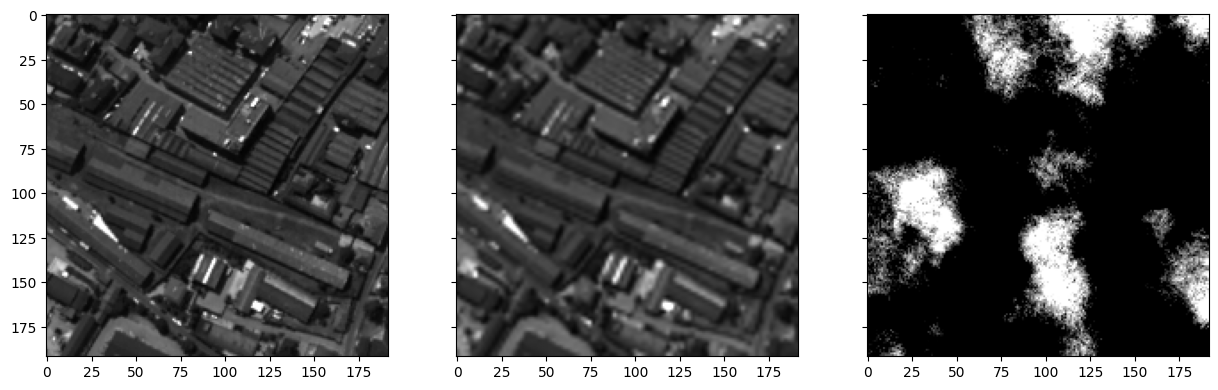

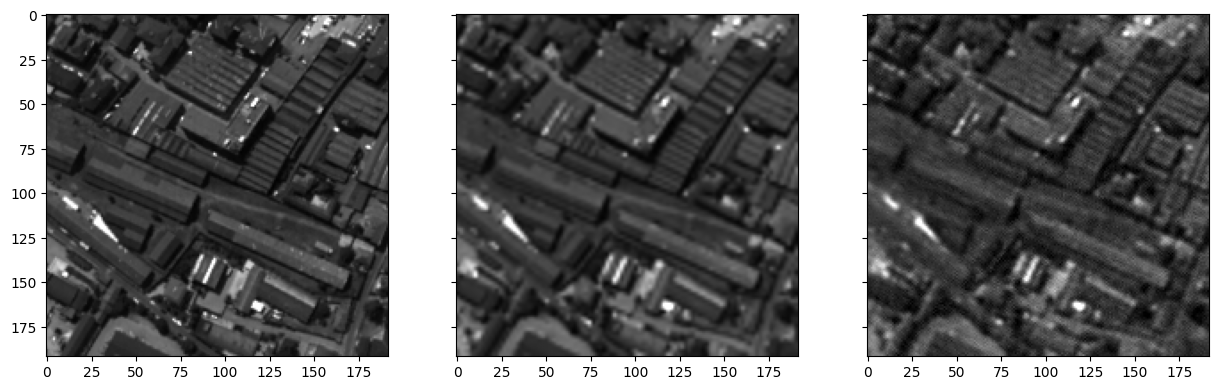

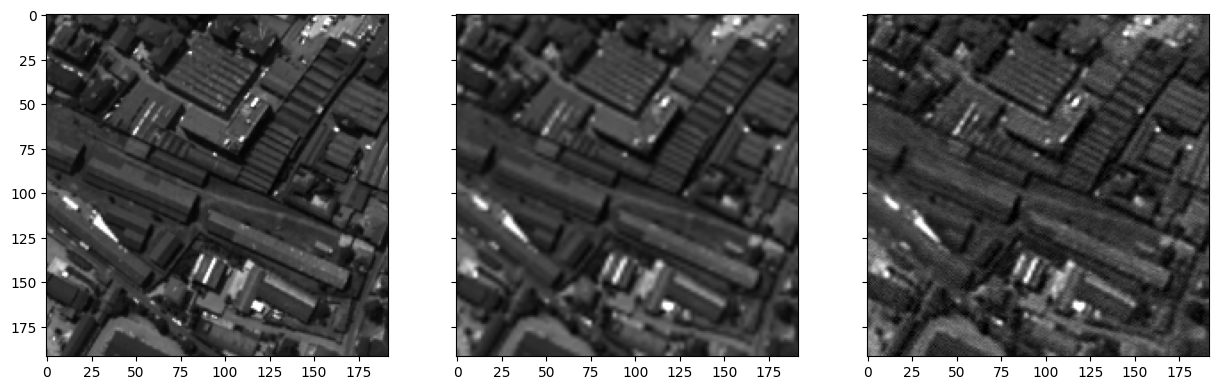

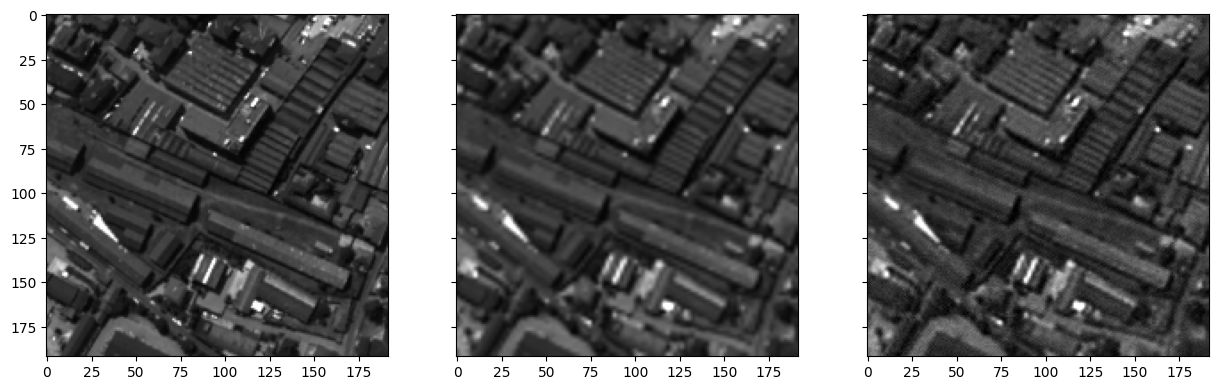

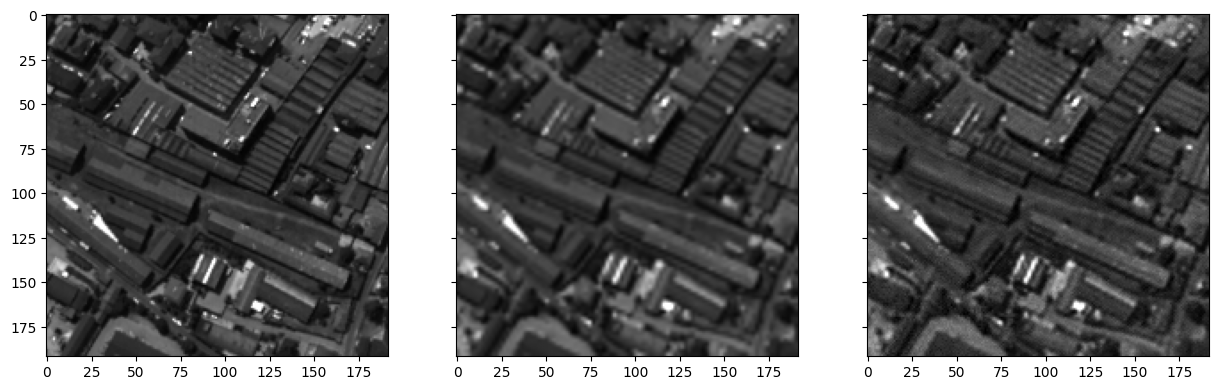

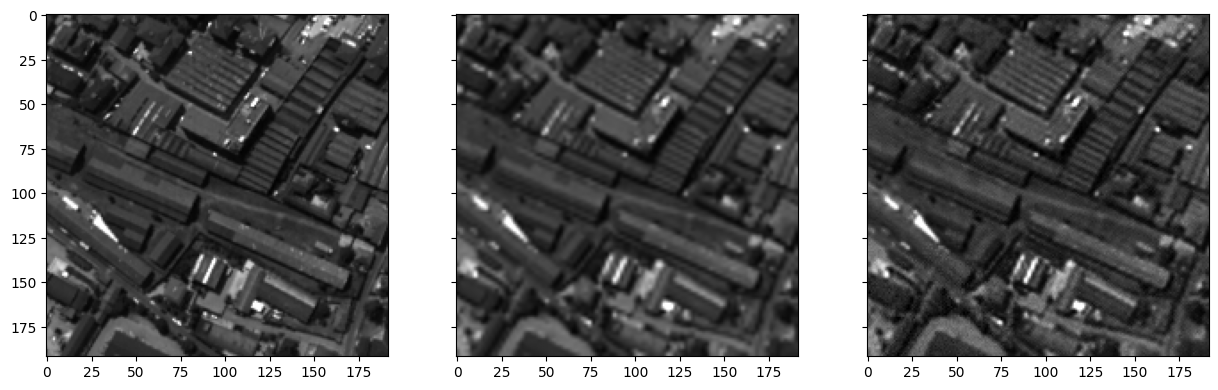

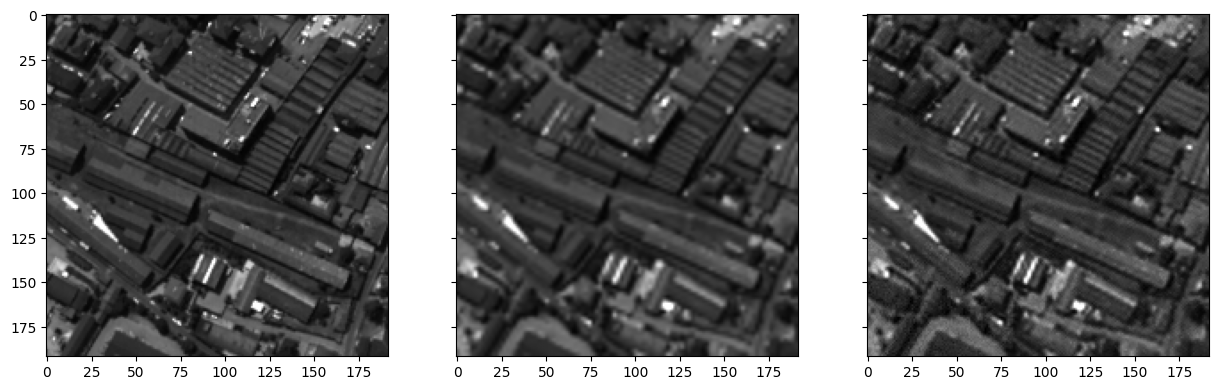

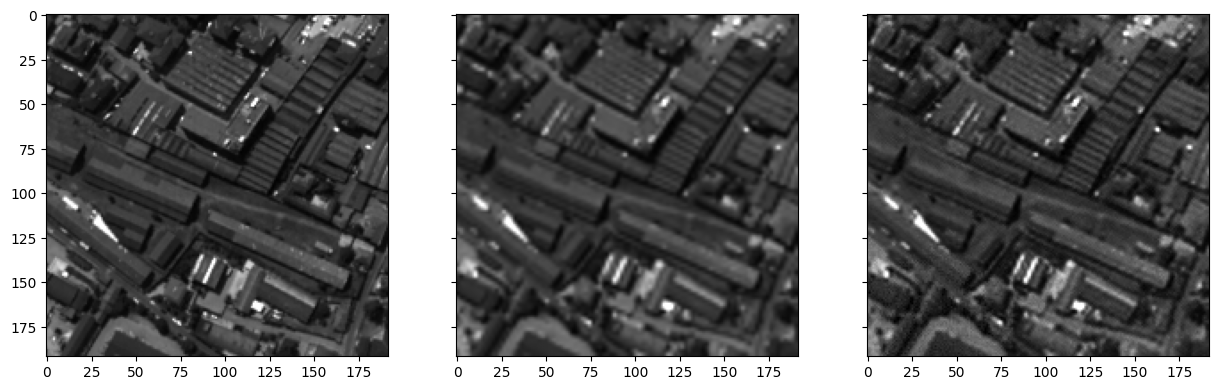

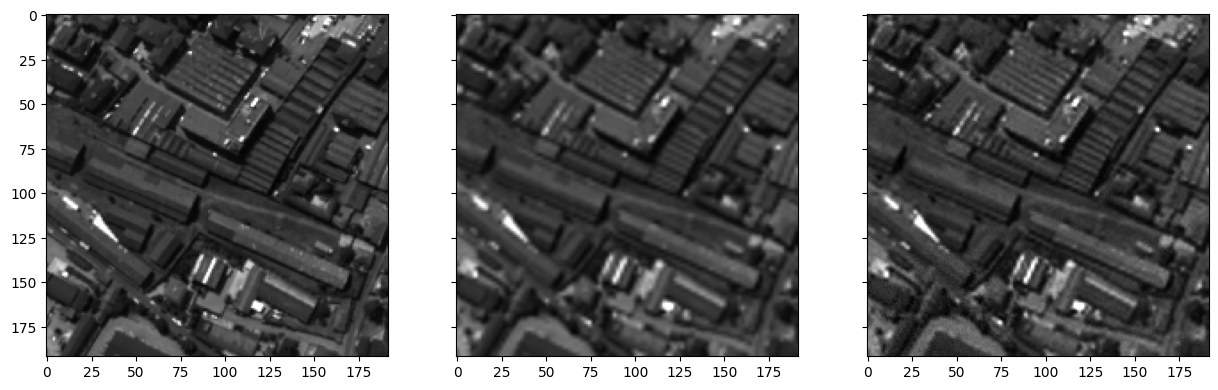

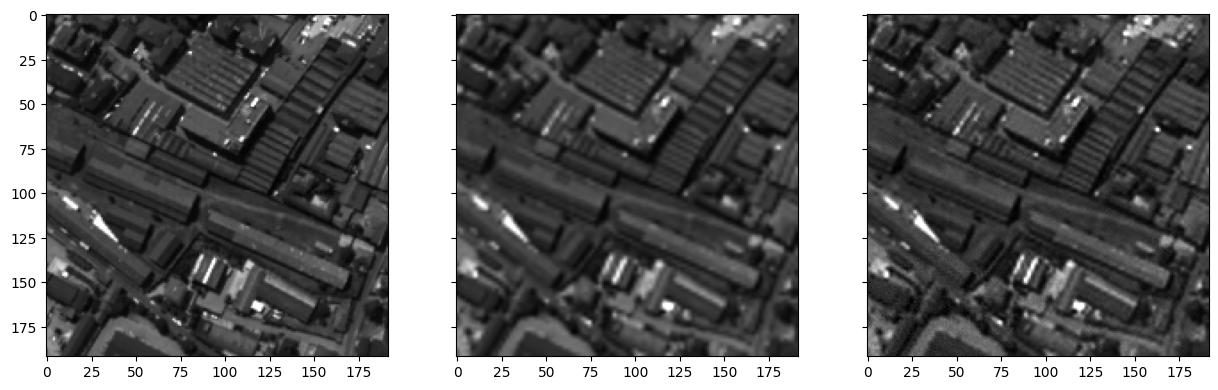

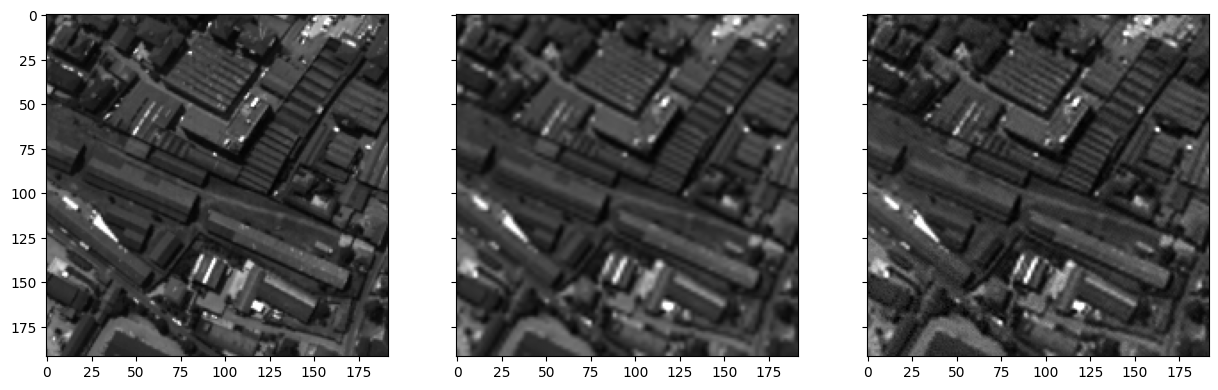

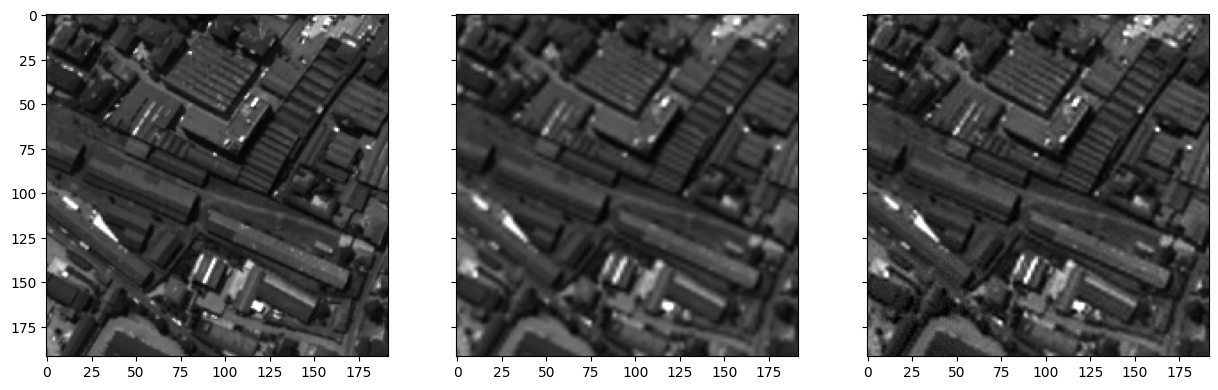

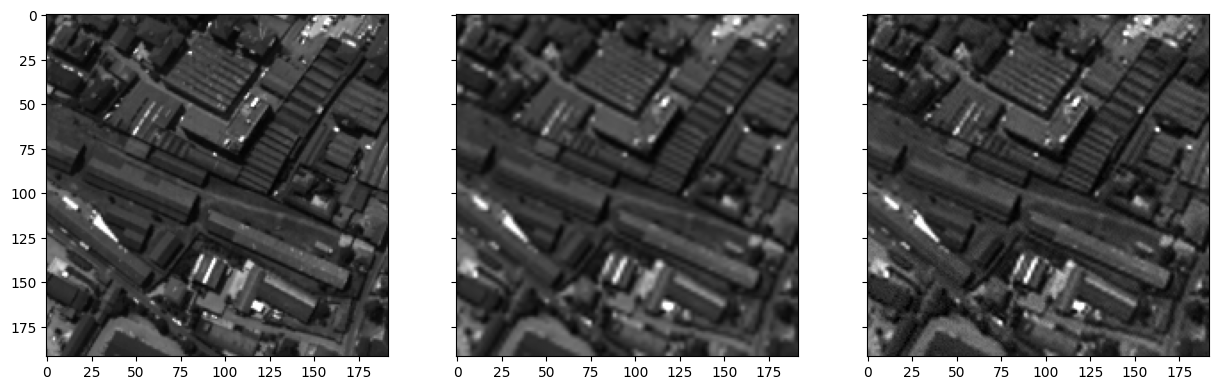

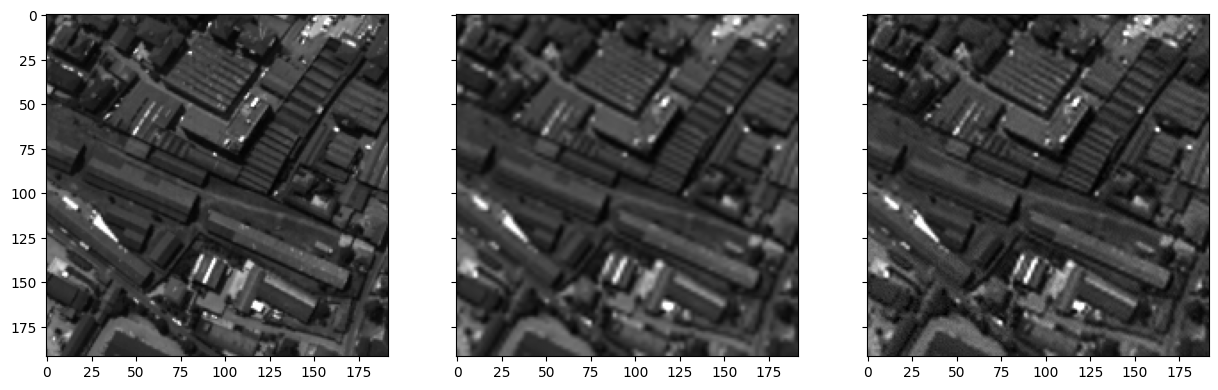

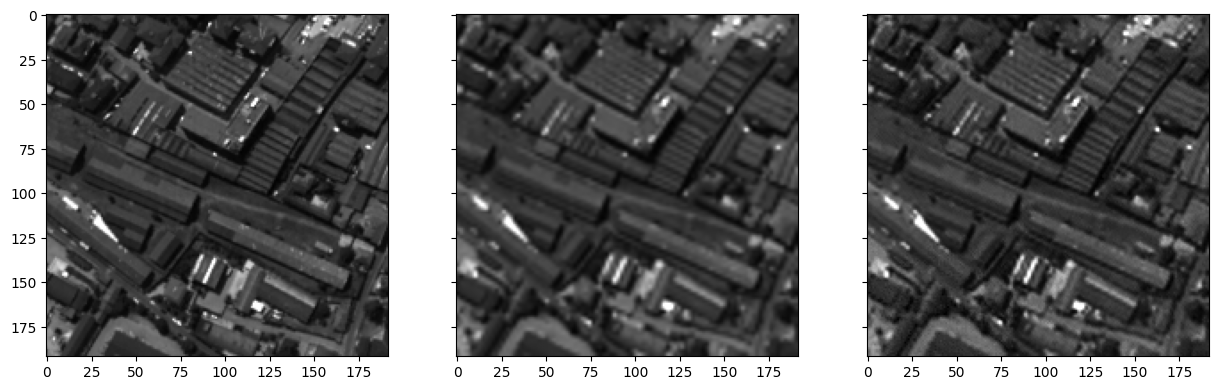

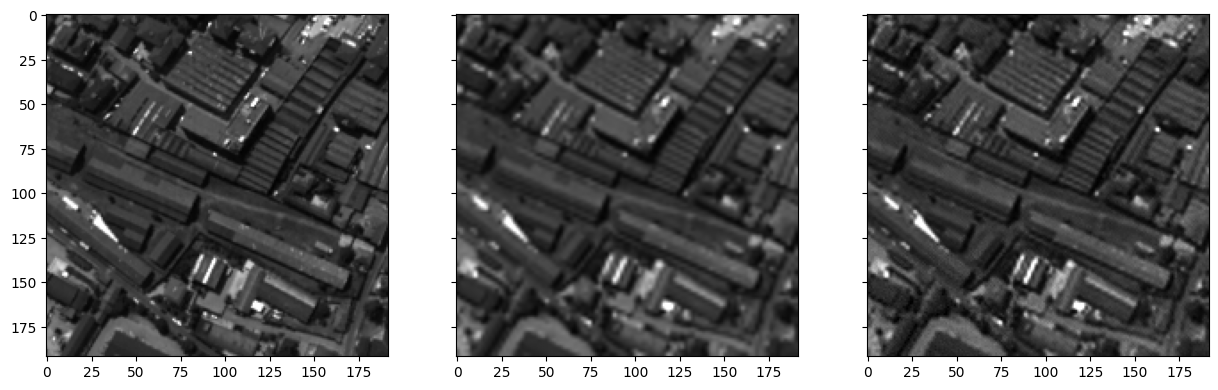

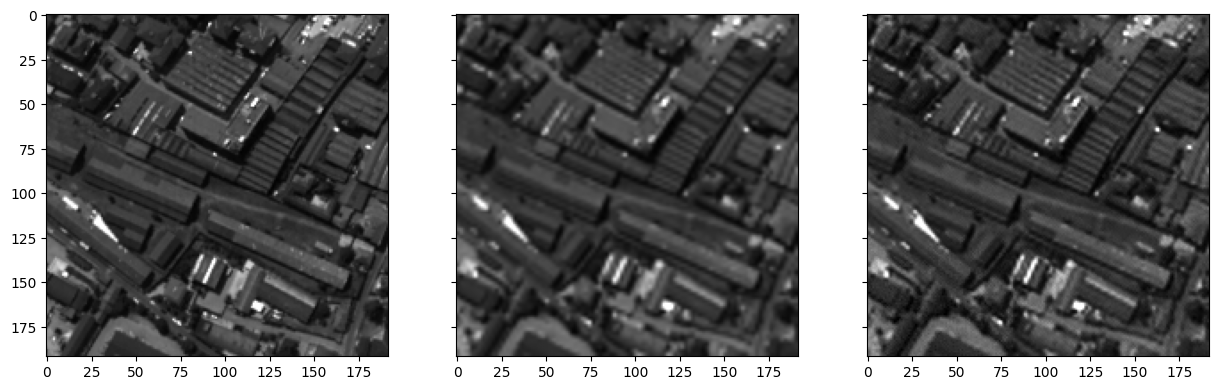

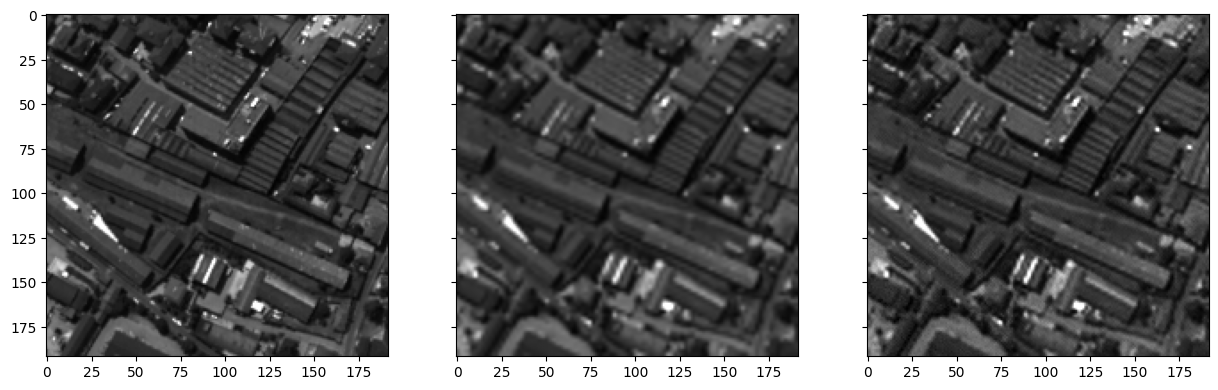

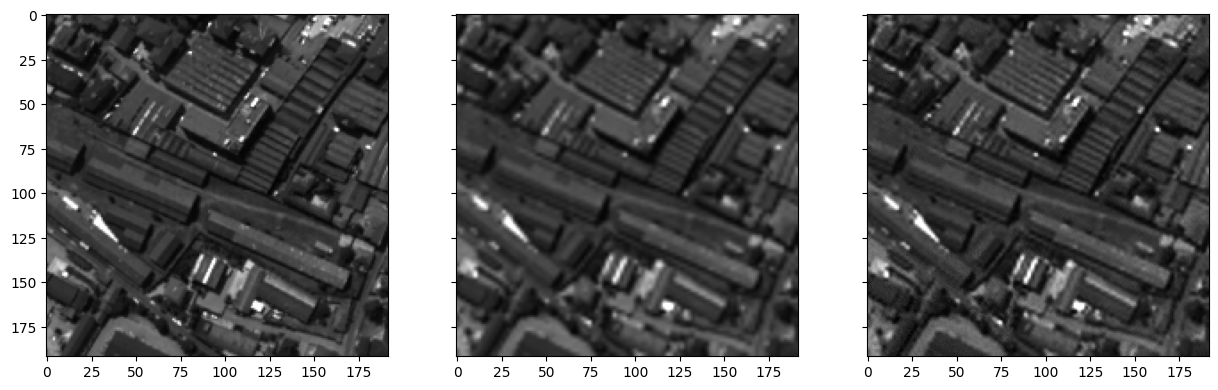

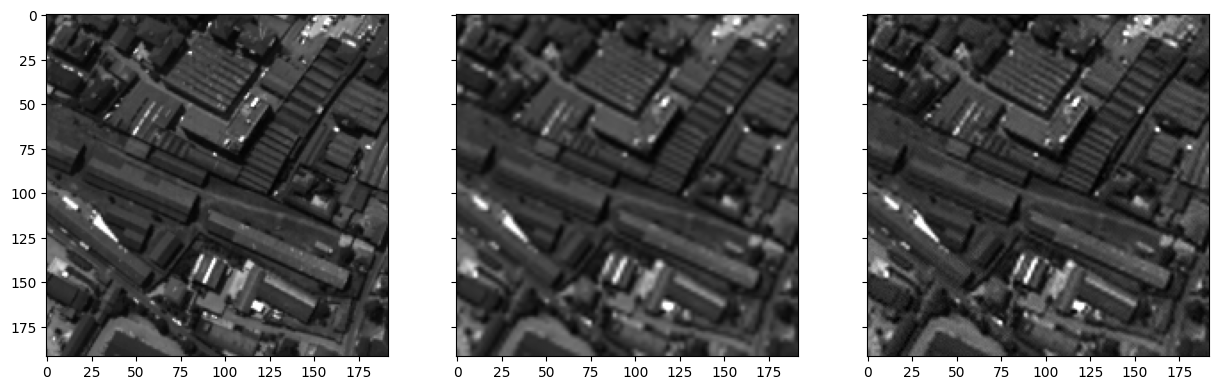

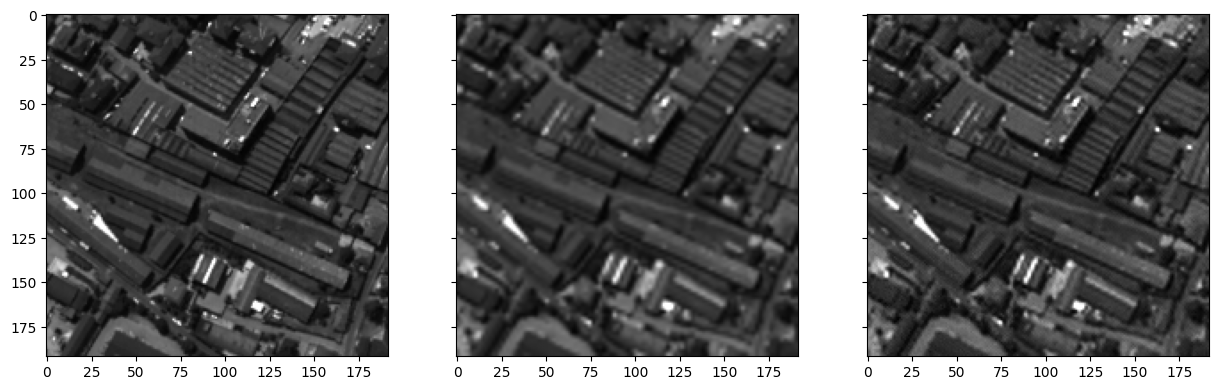

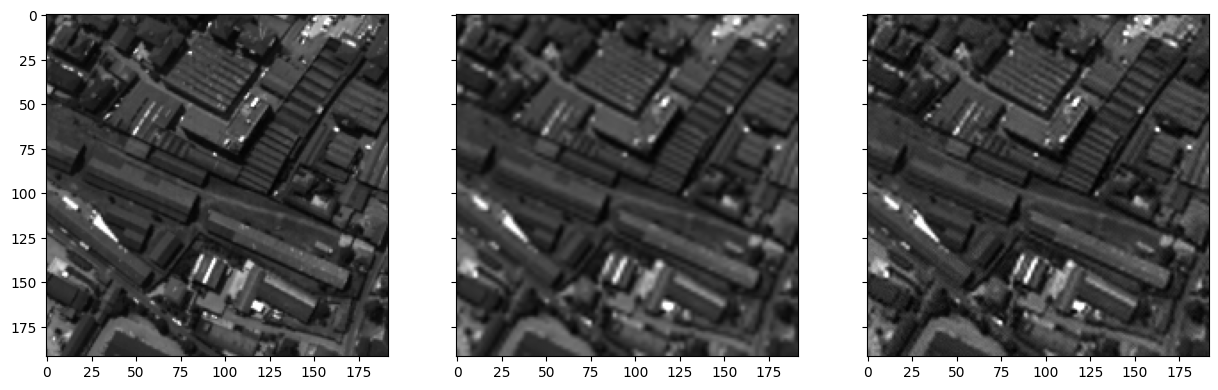

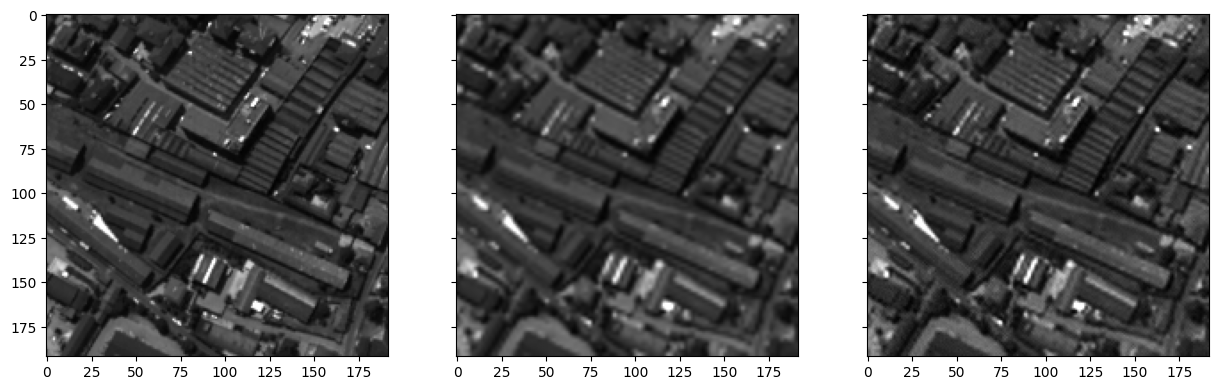

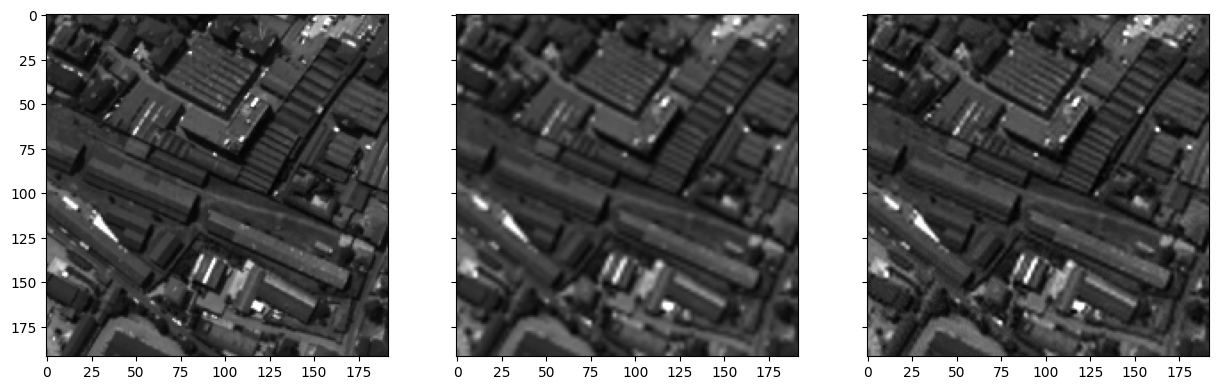

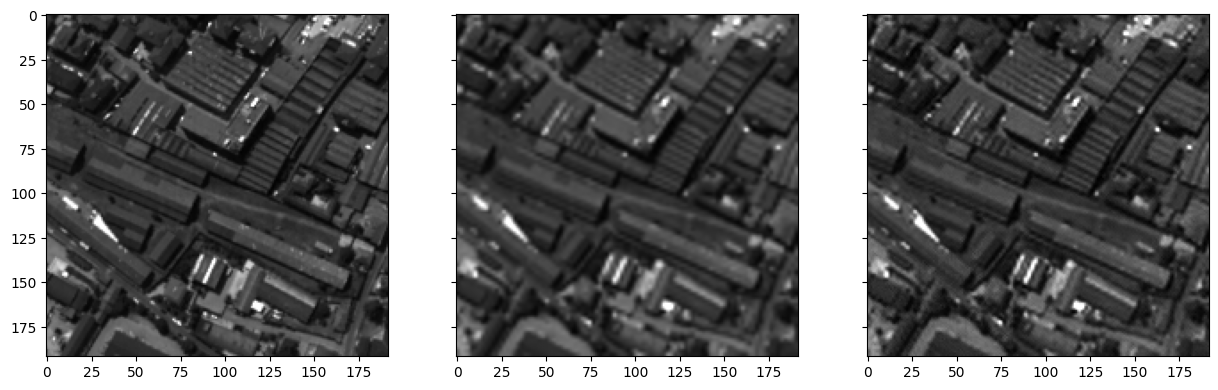

In [ ]:
# psnr_history = [] 
# net_input_saved = net_input.detach().clone()
# noise = net_input.detach().clone()

i = 0
p = get_params(OPT_OVER, net, net_input)
optimize(OPTIMIZER, p, closure, LR, num_iter)